In [6]:
import pandas as pd

url = "https://raw.githubusercontent.com/jennybc/gapminder/main/inst/extdata/gapminder.tsv"
df = pd.read_csv(url, sep="\t")
df.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


In [7]:
#1. Subsetting Rows
#Using loc (by label)
df.loc[0]      # first row
df.loc[99]     # 100th row
df.tail(1)     # last row
df.loc[[0, 99, 999]]   # multiple rows

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
99,Bangladesh,Asia,1967,43.453,62821884,721.186086
999,Mongolia,Asia,1967,51.253,1149500,1226.041130


In [8]:
#Using iloc (by position)
df.iloc[1]     # 2nd row
df.iloc[99]    # 100th row
df.iloc[-1]    # last row
df.iloc[[0, 99, 999]]

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
99,Bangladesh,Asia,1967,43.453,62821884,721.186086
999,Mongolia,Asia,1967,51.253,1149500,1226.041130


In [9]:
#2. Subsetting Columns
df.loc[:, ['year', 'pop']]        # using names
df.iloc[:, [2, 4, -1]]            # using index

,year,pop,gdpPercap
0,1952,8425333,779.445314
1,1957,9240934,820.853030
2,1962,10267083,853.100710
3,1967,11537966,836.197138
4,1972,13079460,739.981106
...,...,...,...
1699,1987,9216418,706.157306
1700,1992,10704340,693.420786
1701,1997,11404948,792.449960
1702,2002,11926563,672.038623


In [10]:
#3. Subsetting Column Ranges
small_range = list(range(5))
df.iloc[:, small_range]

,country,continent,year,lifeExp,pop
0,Afghanistan,Asia,1952,28.801,8425333
1,Afghanistan,Asia,1957,30.332,9240934
2,Afghanistan,Asia,1962,31.997,10267083
3,Afghanistan,Asia,1967,34.020,11537966
4,Afghanistan,Asia,1972,36.088,13079460
...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418
1700,Zimbabwe,Africa,1992,60.377,10704340
1701,Zimbabwe,Africa,1997,46.809,11404948
1702,Zimbabwe,Africa,2002,39.989,11926563


In [11]:
#4. Access Specific Cell
df.loc[42, 'country']
df.iloc[42, 0]

'Angola'

In [12]:
#5. Subsetting Rows AND Columns
df.iloc[[0, 99, 999], [0, 3, 5]]

,country,lifeExp,gdpPercap
0,Afghanistan,28.801,779.445314
99,Bangladesh,43.453,721.186086
999,Mongolia,51.253,1226.041130


In [13]:
#6. Grouped Mean (Very Important)
# Example: Average life expectancy per year

df.groupby('year')['lifeExp'].mean()

year
1952    49.057620
1957    51.507401
1962    53.609249
1967    55.678290
1972    57.647386
1977    59.570157
1982    61.533197
1987    63.212613
1992    64.160338
1997    65.014676
2002    65.694923
2007    67.007423
Name: lifeExp, dtype: float64

In [14]:
#Reset index (flatten):

df.groupby('year')['lifeExp'].mean().reset_index()

,year,lifeExp
0,1952,49.057620
1,1957,51.507401
2,1962,53.609249
3,1967,55.678290
4,1972,57.647386
5,1977,59.570157
6,1982,61.533197
7,1987,63.212613
8,1992,64.160338
9,1997,65.014676


In [15]:
#7. Frequency Counts
df['continent'].nunique()
df['continent'].value_counts()

continent
Africa      624
Asia        396
Europe      360
Americas    300
Oceania      24
Name: count, dtype: int64

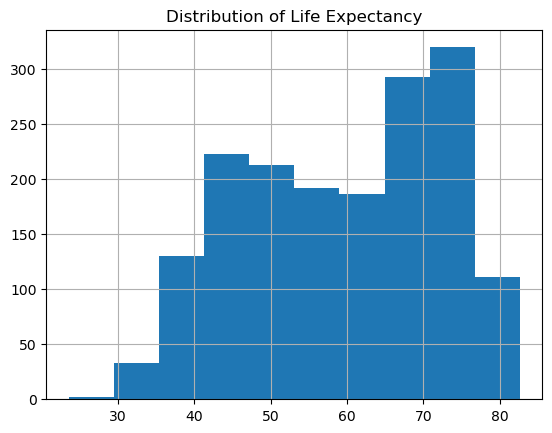

In [16]:
#8. Basic Visualization
#Histogram
import matplotlib.pyplot as plt

df['lifeExp'].hist()
plt.title("Distribution of Life Expectancy")
plt.show()

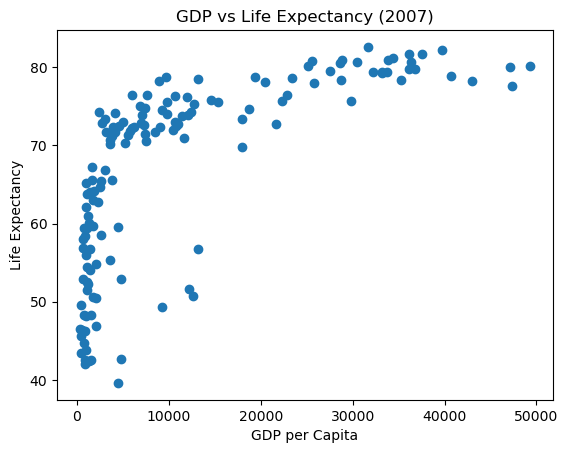

In [17]:
#Scatter Plot
df_2007 = df[df['year'] == 2007]

plt.scatter(df_2007['gdpPercap'], df_2007['lifeExp'])
plt.xlabel("GDP per Capita")
plt.ylabel("Life Expectancy")
plt.title("GDP vs Life Expectancy (2007)")
plt.show()

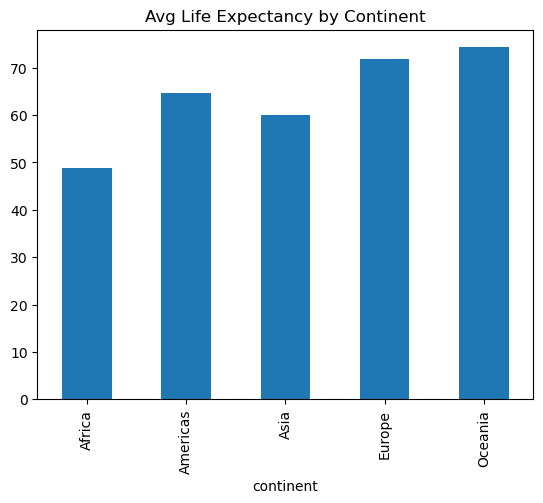

In [18]:
#Bar Chart (Grouped Mean)
continent_mean = df.groupby('continent')['lifeExp'].mean()

continent_mean.plot(kind='bar')
plt.title("Avg Life Expectancy by Continent")
plt.show()

In [ ]:
#PRACTICE QUESTIONS

In [24]:
#Print 10th row
df.iloc[9]

country      Afghanistan
continent           Asia
year                1997
lifeExp           41.763
pop             22227415
gdpPercap     635.341351
Name: 9, dtype: object

In [22]:
#Q2: Show only country & GDP columns
df[['country', 'gdpPercap']].head()


,country,gdpPercap
0,Afghanistan,779.445314
1,Afghanistan,820.853030
2,Afghanistan,853.100710
3,Afghanistan,836.197138
4,Afghanistan,739.981106


In [21]:
#Q3: Rows for India only
df[df['country'] == 'India']

,country,continent,year,lifeExp,pop,gdpPercap
696,India,Asia,1952,37.373,372000000,546.565749
697,India,Asia,1957,40.249,409000000,590.061996
698,India,Asia,1962,43.605,454000000,658.347151
699,India,Asia,1967,47.193,506000000,700.770611
700,India,Asia,1972,50.651,567000000,724.032527
701,India,Asia,1977,54.208,634000000,813.337323
702,India,Asia,1982,56.596,708000000,855.723538
703,India,Asia,1987,58.553,788000000,976.512676
704,India,Asia,1992,60.223,872000000,1164.406809
705,India,Asia,1997,61.765,959000000,1458.817442


In [23]:
#Q4: Average life expectancy by continent
df.groupby('continent')['lifeExp'].mean()

continent
Africa      48.865330
Americas    64.658737
Asia        60.064903
Europe      71.903686
Oceania     74.326208
Name: lifeExp, dtype: float64

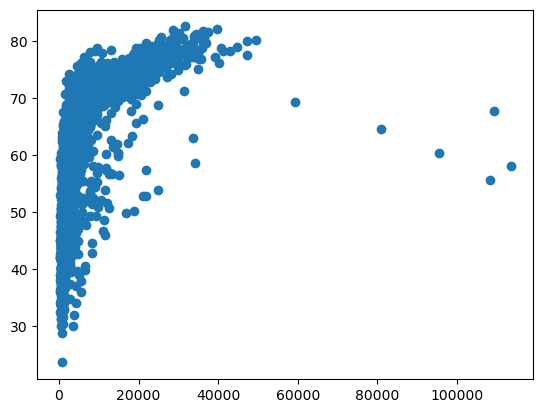

In [25]:
#Q6: Scatter plot GDP vs LifeExp
plt.scatter(df['gdpPercap'], df['lifeExp'])
plt.show()


In [ ]:
##----- Types of Graphs Covered -----##
#Histogram
#Frequency Polygon
#Ogive
#Pie Chart
#Pareto Chart
#Scatter Plot
#Bar Chart

#-----------------------------------#

#----- Principles of Good Graphs ------#
#No distortion
#Start vertical axis at zero
#Proper labels
#Clear title
#Avoid chart junk